In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition (4).csv")
print(f"dataset contient {df.shape[0] } lignes X {df.shape[1]}colonnes")

dataset contient 1470 lignes X 35colonnes


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df=df.drop(columns=['EmployeeCount',
    'Over18',
    'StandardHours',
    'DailyRate',
    'HourlyRate',
    'MonthlyRate','TotalWorkingYears',
    'YearsInCurrentRole',
   'YearsWithCurrManager', 'BusinessTravel',
        'EnvironmentSatisfaction', 'Gender',
       'MaritalStatus','NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TrainingTimesLastYear',
       'YearsSinceLastPromotion'], errors='ignore')

In [ ]:
df.columns

Index(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EmployeeNumber', 'JobInvolvement', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MonthlyIncome', 'WorkLifeBalance',
       'YearsAtCompany'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1470 non-null   int64 
 1   Attrition         1470 non-null   object
 2   Department        1470 non-null   object
 3   DistanceFromHome  1470 non-null   int64 
 4   Education         1470 non-null   int64 
 5   EducationField    1470 non-null   object
 6   EmployeeNumber    1470 non-null   int64 
 7   JobInvolvement    1470 non-null   int64 
 8   JobLevel          1470 non-null   int64 
 9   JobRole           1470 non-null   object
 10  JobSatisfaction   1470 non-null   int64 
 11  MonthlyIncome     1470 non-null   int64 
 12  WorkLifeBalance   1470 non-null   int64 
 13  YearsAtCompany    1470 non-null   int64 
dtypes: int64(10), object(4)
memory usage: 160.9+ KB


In [ ]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeNumber,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,1024.865306,2.729932,2.063946,2.728571,6502.931293,2.761224,7.008163
std,9.135373,8.106864,1.024165,602.024335,0.711561,1.106940,1.102846,4707.956783,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,491.250000,2.000000,1.000000,2.000000,2911.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,1020.500000,3.000000,2.000000,3.000000,4919.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,1555.750000,3.000000,3.000000,4.000000,8379.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,2068.000000,4.000000,5.000000,4.000000,19999.000000,4.000000,40.000000


In [ ]:
df["Attrition"]

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No
...,...
1465,No
1466,No
1467,No
1468,No


In [ ]:
df["attrition"]=df["Attrition"].map({"Yes":1,"No":0})

In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeNumber,0
JobInvolvement,0
JobLevel,0
JobRole,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df["Attrition"].value_counts())


Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
salaire_negative=(df["MonthlyIncome"]<=0).sum()
print(salaire_negative)

0


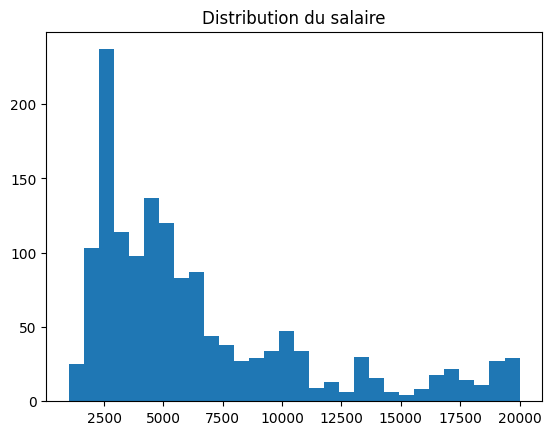

In [ ]:
plt.hist(df['MonthlyIncome'], bins=30)

plt.title("Distribution du salaire")

plt.show()

In [ ]:
df['Department'].value_counts()


,count
Department,
Research & Development,961
Sales,446
Human Resources,63


Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


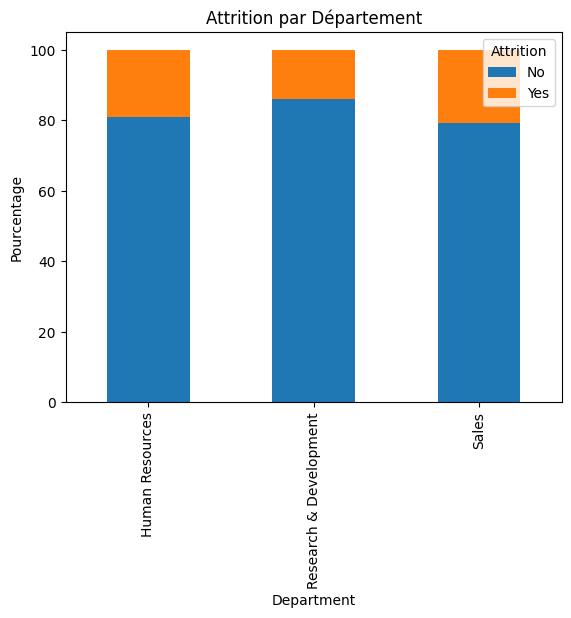

In [ ]:
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
print(dept_attrition)

# Graphique
dept_attrition.plot(kind='bar', stacked=True)
plt.title("Attrition par Département")
plt.ylabel("Pourcentage")
plt.show()

In [ ]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


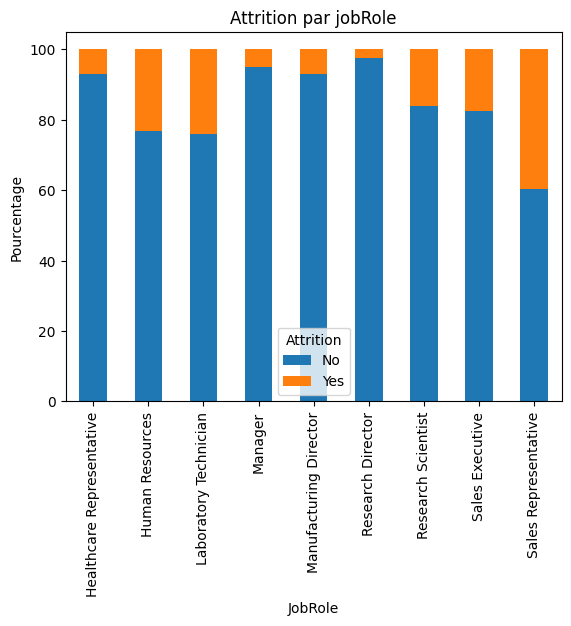

In [ ]:
job_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
print(job_attrition)

# Graphique
job_attrition.plot(kind='bar', stacked=True)
plt.title("Attrition par jobRole")
plt.ylabel("Pourcentage")
plt.show()

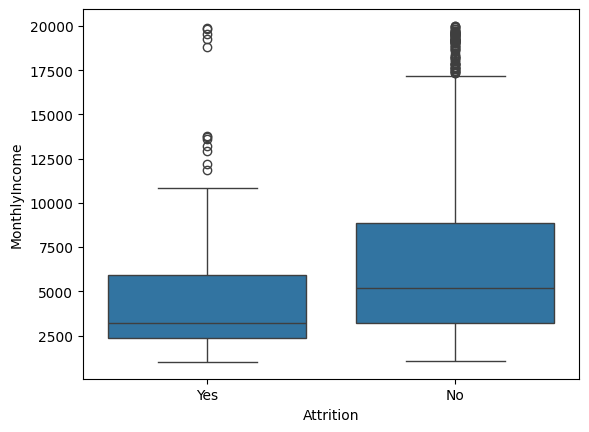

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

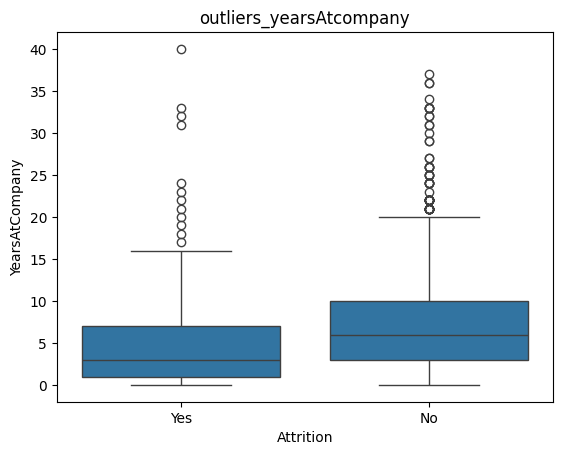

In [ ]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("outliers_yearsAtcompany")
plt.show()

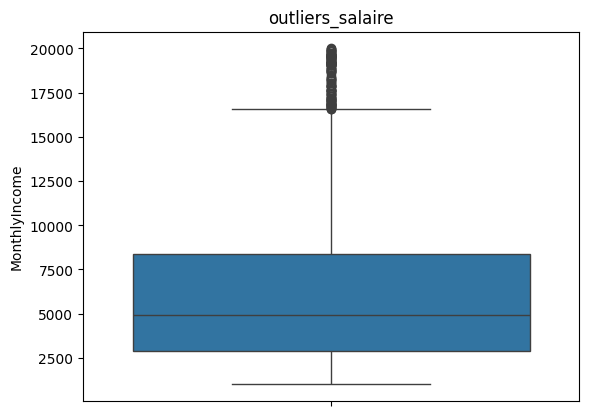

In [ ]:
sns.boxplot(df['MonthlyIncome'])
plt.title("outliers_salaire")
plt.show()

In [ ]:
Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)
IQR=Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound=Q3 + 1.5 * IQR
print(f"Q1 ={Q1:.2f} / Q3 = {Q3:.2f} / IQR= {IQR:.2f}")
print(f"Borne inferieure: {lower_bound:.2f}")
print(f"borne superieure: {upper_bound:.2f}")
outliers = df[(df['MonthlyIncome'] < lower_bound) |
              (df['MonthlyIncome'] > upper_bound)]
print(outliers)

Q1 =2911.00 / Q3 = 8379.00 / IQR= 5468.00
Borne inferieure: -5291.00
borne superieure: 16581.00
      Age Attrition              Department  DistanceFromHome  Education  \
25     53        No  Research & Development                 5          3   
29     46        No                   Sales                 2          4   
45     41       Yes  Research & Development                12          3   
62     50        No  Research & Development                 7          2   
105    59        No         Human Resources                 2          4   
...   ...       ...                     ...               ...        ...   
1374   58        No                   Sales                21          3   
1377   49        No  Research & Development                 2          1   
1401   55        No         Human Resources                26          4   
1437   39        No  Research & Development                 9          3   
1443   42        No  Research & Development                 2       

<Axes: >

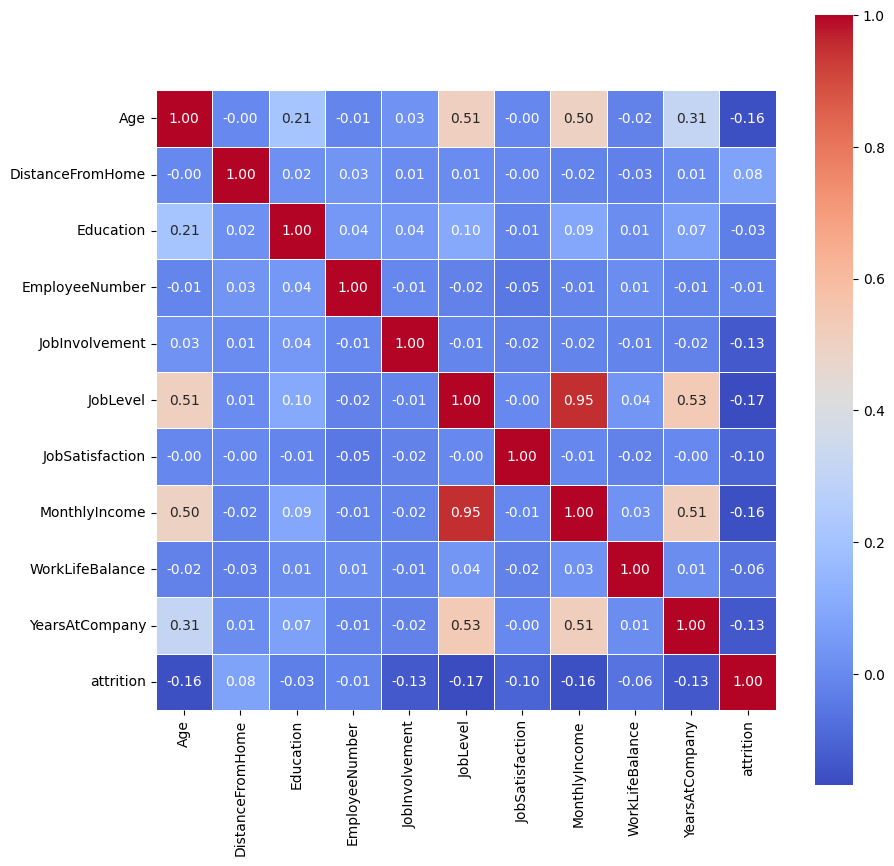

In [ ]:
#matrice de correlation
plt.figure(figsize=(10,10))
df_num=df.select_dtypes(include=["int64","float64"])
sns.heatmap(df_num.corr(), annot=True,cmap="coolwarm", linewidths=0.5,fmt=".2f",square=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,Age,DistanceFromHome,Education,EmployeeNumber,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,WorkLifeBalance,YearsAtCompany,attrition
0,0.446350,-1.010909,-0.891688,-1.701283,0.379672,-0.057788,1.153254,-0.108350,-2.493820,-0.164613,2.280906
1,1.322365,-0.147150,-1.868426,-1.699621,-1.026167,-0.057788,-0.660853,-0.291719,0.338096,0.488508,-0.438422
2,0.008343,-0.887515,-0.891688,-1.696298,-1.026167,-0.961486,0.246200,-0.937654,0.338096,-1.144294,2.280906
3,-0.429664,-0.764121,1.061787,-1.694636,0.379672,-0.961486,0.246200,-0.763634,0.338096,0.161947,-0.438422
4,-1.086676,-0.887515,-1.868426,-1.691313,0.379672,-0.961486,-0.660853,-0.644858,0.338096,-0.817734,-0.438422


In [ ]:
tab=pd.crosstab(df["Attrition"],df["Department"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre Département et Attrition")
else:
    print(" -->Pas de relation significative")


chi2= 10.80
p= 0.00
ddl= 2
exepted= [[ 52.84285714 806.06326531 374.09387755]
 [ 10.15714286 154.93673469  71.90612245]]
--> Il existe une relation entre Département et Attrition


In [ ]:
tab=pd.crosstab(df["Attrition"],df["JobRole"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre JobRole et Attrition")
else:
    print(" -->Pas de relation significative")

chi2= 86.19
p= 0.00
ddl= 8
exepted= [[109.87959184  43.61632653 217.24285714  85.55510204 121.62244898
   67.10204082 244.92244898 273.44081633  69.61836735]
 [ 21.12040816   8.38367347  41.75714286  16.44489796  23.37755102
   12.89795918  47.07755102  52.55918367  13.38163265]]
--> Il existe une relation entre JobRole et Attrition


In [ ]:
tab=pd.crosstab(df["Attrition"],df["MonthlyIncome"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre MonthlyIncome et Attrition")
else:
    print(" -->Pas de relation significative")

chi2= 1319.02
p= 0.71
ddl= 1348
exepted= [[0.83877551 0.83877551 0.83877551 ... 0.83877551 0.83877551 0.83877551]
 [0.16122449 0.16122449 0.16122449 ... 0.16122449 0.16122449 0.16122449]]
 -->Pas de relation significative


In [ ]:
tab=pd.crosstab(df["Attrition"],df["JobSatisfaction"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre JobSatisfaction et Attrition")
else:
    print(" -->Pas de relation significative")

chi2= 17.51
p= 0.00
ddl= 3
exepted= [[242.40612245 234.85714286 370.73877551 384.99795918]
 [ 46.59387755  45.14285714  71.26122449  74.00204082]]
--> Il existe une relation entre JobSatisfaction et Attrition


In [ ]:
tab=pd.crosstab(df["Attrition"],df["Education"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre Education et Attrition")
else:
    print(" -->Pas de relation significative")

chi2= 3.07
p= 0.55
ddl= 4
exepted= [[142.59183673 236.53469388 479.77959184 333.83265306  40.26122449]
 [ 27.40816327  45.46530612  92.22040816  64.16734694   7.73877551]]
 -->Pas de relation significative


In [ ]:
tab=pd.crosstab(df["Attrition"],df["YearsAtCompany"])
tab
chi2,p,ddl,exepted=chi2_contingency(tab)
print(f"chi2= {chi2:.2f}")
print(f"p= {p:.2f}")
print(f"ddl= {ddl}")
print(f"exepted= {exepted}")
if p < 0.05:
    print("--> Il existe une relation entre YearsAtCompany et Attrition")
else:
    print(" -->Pas de relation significative")

chi2= 95.39
p= 0.00
ddl= 36
exepted= [[3.69061224e+01 1.43430612e+02 1.06524490e+02 1.07363265e+02
  9.22653061e+01 1.64400000e+02 6.37469388e+01 7.54897959e+01
  6.71020408e+01 6.87795918e+01 1.00653061e+02 2.68408163e+01
  1.17428571e+01 2.01306122e+01 1.50979592e+01 1.67755102e+01
  1.00653061e+01 7.54897959e+00 1.09040816e+01 9.22653061e+00
  2.26469388e+01 1.17428571e+01 1.25816327e+01 1.67755102e+00
  5.03265306e+00 3.35510204e+00 3.35510204e+00 1.67755102e+00
  1.67755102e+00 8.38775510e-01 2.51632653e+00 2.51632653e+00
  4.19387755e+00 8.38775510e-01 1.67755102e+00 8.38775510e-01
  8.38775510e-01]
 [7.09387755e+00 2.75693878e+01 2.04755102e+01 2.06367347e+01
  1.77346939e+01 3.16000000e+01 1.22530612e+01 1.45102041e+01
  1.28979592e+01 1.32204082e+01 1.93469388e+01 5.15918367e+00
  2.25714286e+00 3.86938776e+00 2.90204082e+00 3.22448980e+00
  1.93469388e+00 1.45102041e+00 2.09591837e+00 1.77346939e+00
  4.35306122e+00 2.25714286e+00 2.41836735e+00 3.22448980e-01
  9.67346939e-0

In [ ]:
# Ensure 'attrition' column is discrete (0 or 1) for the classifier
df['attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=["Attrition", "attrition"], axis=1)
y = df["attrition"]

# One-hot encode categorical columns in X
X = pd.get_dummies(X, columns=['Department', 'EducationField', 'JobRole'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"x_train:{x_train.shape} exemples")
print(f"x_test:{x_test.shape} exemples")

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

x_train:(1176, 25) exemples
x_test:(294, 25) exemples


In [ ]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
pct_error = (rmse * 100) / y_test.mean()


print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {R2:.2f}")


MSE: 0.13
MAE: 0.13


NameError: name 'R2' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred=model.predict(x_test)
print("Accuracy =", accuracy_score(y_test, y_pred))

print("\nMatrice confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport classification :")
print(classification_report(y_test, y_pred))

In [ ]:
importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': model.feature_importances_
})

print("\nImportance des variables :")
print(importance.sort_values(by='Importance', ascending=False))

new_employee = pd.DataFrame([[
    28,
    0,
    1,
    5,
    3,
    2,
    9999,
    3,
    1,
    4,
    2,
    3000,
    3,
    1
]])


prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("\n Employé à risque de départ")
else:
    print("\n Employé stable")